In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
SEED = 25


In [14]:
df = pd.read_csv(r'D:\hse_iot\VKR\my_inspector\data\classification_dataset.csv')
df['class'] = round(df['class'] / 10).astype(int)
df = df[df['class'] != 1]
_type = df['type'].to_list()
df = df.drop(['name', 'side_mistake',
              'vs', 'squared_vs', 'ttr', 'root_ttr',
              'log_ttr', 'uber_ttr', 'd', 'vvi',
              'squared_vv', 'punct_mistakes_pp',
              'punct_mistakes_because',
              'punct_mistakes_but', 'punct_mistakes_compare'], axis=1)

df.head(2)

,av_depth,max_depth,min_depth,num_acl,num_rel_cl,num_advcl,num_sent,num_tok,av_tok_before_root,av_len_sent,...,num_linkings,num_4grams,num_func_ngrams,num_shell_noun,num_misspelled_tokens,million_mistake,text,class,type,sum_punct
0,3.56,6,2,2,0,1,18,244,4.39,13.56,...,5,1,0,0,2,0,This two line graphs illustrates monthly avera...,6,1,0
1,5.43,10,4,1,3,1,7,175,6.29,25.00,...,6,1,0,0,3,0,"﻿We have two graphics, which show us the popul...",6,1,0


In [15]:
df.shape

(3440, 62)

In [16]:
df['class'].value_counts()

6    2680
7     308
5     215
4     122
8      77
2      24
3      14
Name: class, dtype: int64

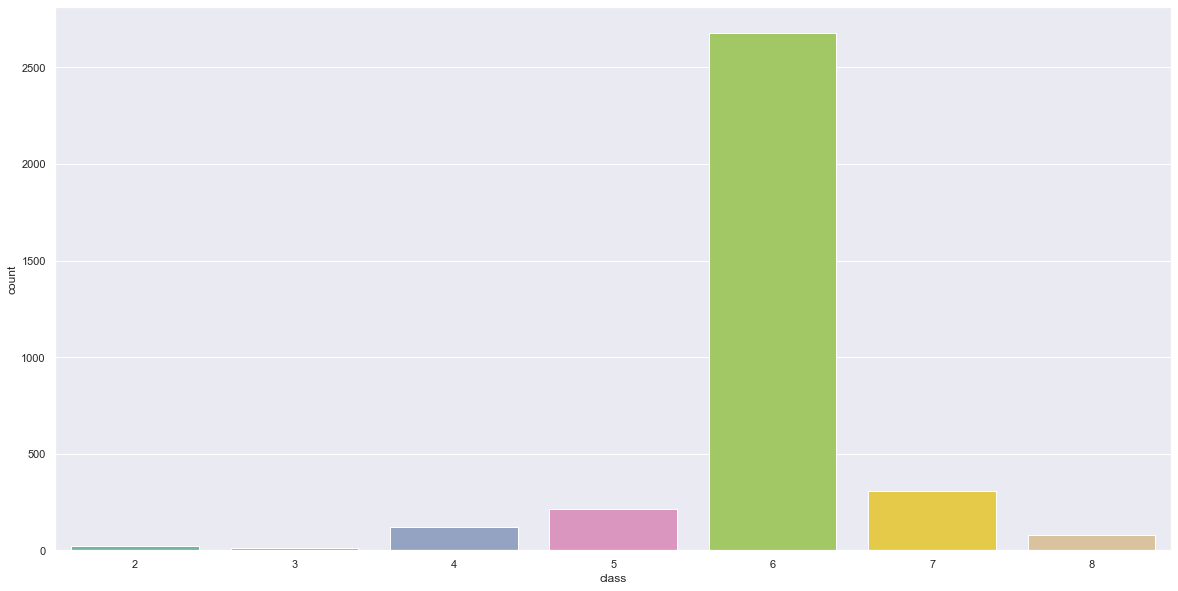

In [17]:
sns.set(rc={'figure.figsize':(20,10)})
sns_plt = sns.countplot(x='class', data=df, palette="Set2")

In [18]:
feature_columns = [col for col in df.columns if col not in ['class', 'name', 'text', 'type']]
X = df[feature_columns]
y = df['class'] - 2
y.loc[y == 1] = 3
y.loc[y == 0] = 3
y.loc[y == 2] = 3
y.loc[y == 5] = 6

y.loc[y == 3] = 0
y.loc[y == 4] = 1
y.loc[y == 6] = 2

In [24]:
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state = SEED)

Так как количество элементов в классах не равномерно то объединим классы 2,3,4,5; 7, 8; и уберем часть элементов из 6 класса

In [25]:
train_y.value_counts()

1    2139
2     322
0     291
Name: class, dtype: int64

In [26]:
dummy = train_y.loc[train_y == 1][:315]
train_y.drop(train_y.loc[train_y == 1].index, inplace=True)
train_y = pd.concat([train_y, dummy], ignore_index=True)
train_y.value_counts()

2    322
1    315
0    291
Name: class, dtype: int64

In [27]:
y_idx = train_y.index
train_x = train_x.iloc[y_idx.to_list()]
train_x.reset_index(inplace=True, drop=True)
test_x.reset_index(inplace=True, drop=True)
train_y = train_y.reset_index(drop=True)
test_y = test_y.reset_index(drop=True)

## Попробуем подобрать различные классификаторы

In [65]:
def model_res(est):
    est.fit(train_x, train_y)
    pred_y = est.predict(test_x)
    cm = confusion_matrix(test_y, pred_y)
    acc = accuracy_score(test_y, pred_y)
    print('Accuracy: ', acc, '\n')
    print('Confusion matrix: \n', cm)

In [191]:
def first_round_search(est, param_grid, num_iter=100):
    grid = RandomizedSearchCV(estimator=est,
                          param_distributions=param_grid,
                          n_iter = num_iter,
                          scoring='accuracy',
                          n_jobs=-1,
                          verbose=1,
                          cv=3,
                          random_state=SEED)
    grid_result = grid.fit(train_x, train_y)
    rs_df = pd.DataFrame(grid_result.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
    rs_df = rs_df.drop([
            'mean_fit_time', 
            'std_fit_time', 
            'mean_score_time',
            'std_score_time', 
            'params',
            'split0_test_score', 
            'split1_test_score', 
            'split2_test_score', 
            'std_test_score'],
            axis=1)
    params_labels = [param for param in rs_df.columns if 'param' in param]
    
    cols = ceil(np.sqrt(len(params_labels)))
    lines = ceil(len(params_labels)/cols)
    fig, axs = plt.subplots(ncols=cols, nrows=lines)
    sns.set(style="whitegrid", color_codes=True, font_scale = 2)
    fig.set_size_inches(30,30)
    
    col = 0
    line = 0
    for param in params_labels:
        sns.barplot(x=param, y='mean_test_score', data=rs_df, ax=axs[line, col])
        axs[line, col].set_ylim([rs_df.groupby(param).mean()['mean_test_score'].min()*0.95,
                                 rs_df.groupby(param).mean()['mean_test_score'].max()*1.05])
        axs[line, col].set_title(label = param.replace('param_', ''), size=25, weight='bold')
        
        if col < cols - 1:
            col += 1
        else:
            line += 1
            col = 0
    

### knn

In [182]:
from sklearn.neighbors import KNeighborsClassifier

In [187]:
param_grid = {'n_neighbors': [int(x) for x in np.linspace(start = 1, stop = 50, num = 20)],
              'p': [1, 2],
              'weights': ['uniform', 'distance']}
param_grid

{'n_neighbors': [1,
  3,
  6,
  8,
  11,
  13,
  16,
  19,
  21,
  24,
  26,
  29,
  31,
  34,
  37,
  39,
  42,
  44,
  47,
  50],
 'p': [1, 2],
 'weights': ['uniform', 'distance']}

1 раунд

C:\Users\Konstantin\.conda\envs\ml_hse\lib\site-packages\sklearn\model_selection\_search.py:278: UserWarning: The total space of parameters 80 is smaller than n_iter=100. Running 80 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Fitting 3 folds for each of 80 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 217 out of 240 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    0.8s finished


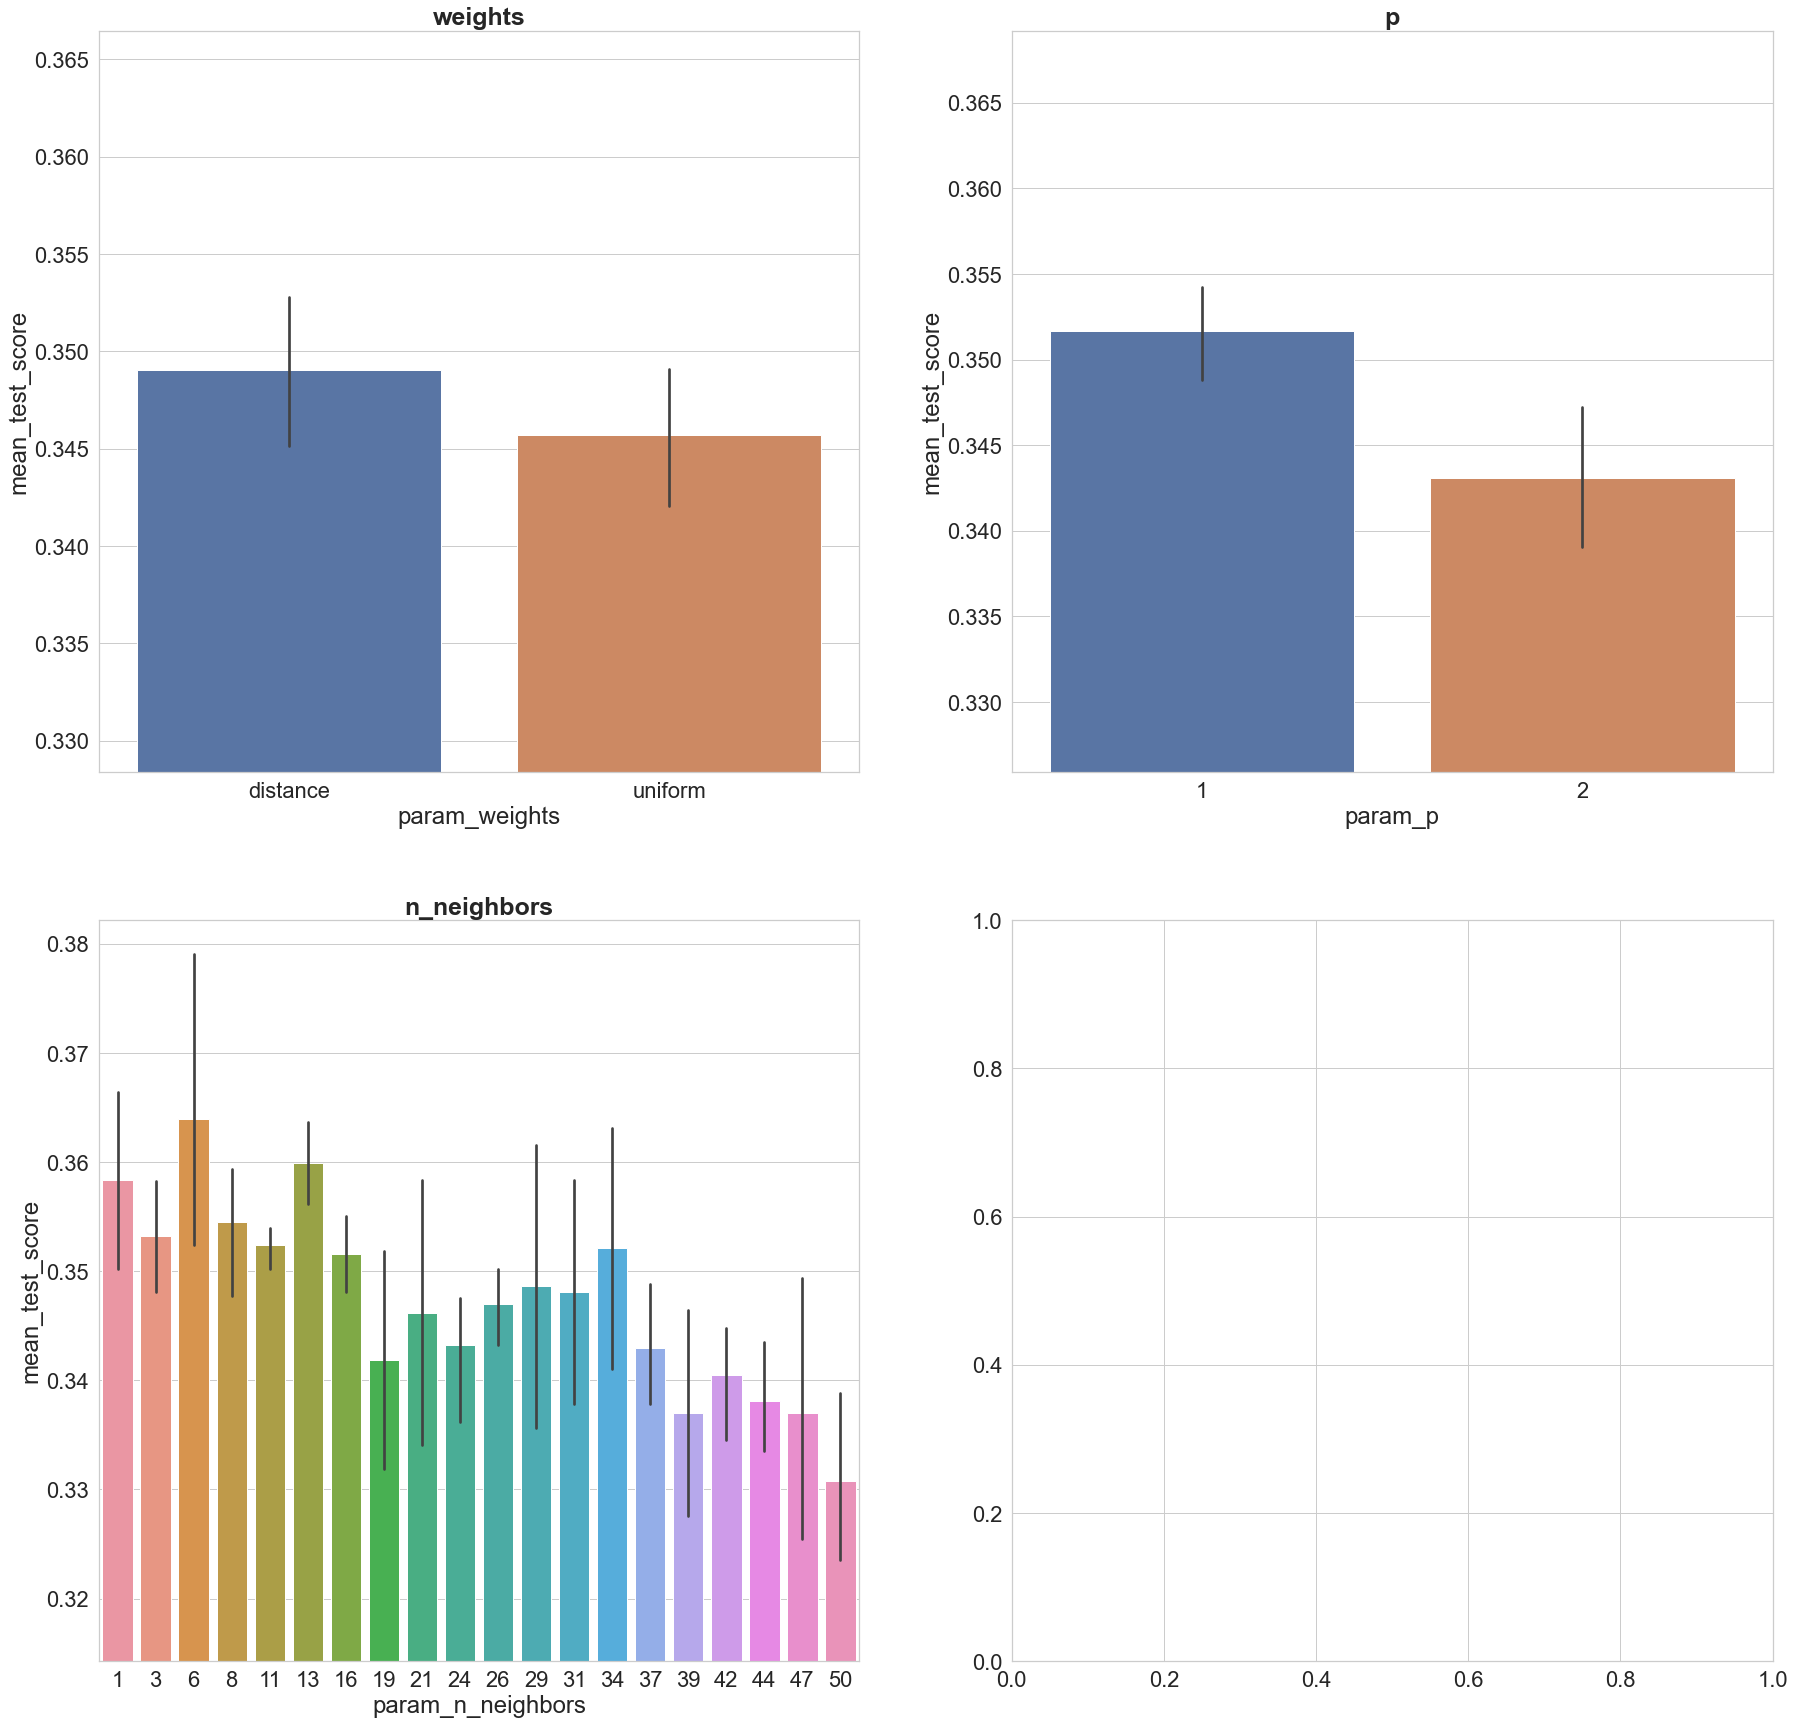

In [193]:
first_round_search(KNeighborsClassifier(metric='minkowski', algorithm='auto'), param_grid, 100)

2 раунд

In [ ]:
param_grid = {'n_neighbors': [4, 5, 6, 7],
              'p': [1,],
              'weights': ['distance',]}
param_grid

In [194]:
grid = GridSearchCV(estimator=KNeighborsClassifier(metric='minkowski', algorithm='auto'), param_grid=param_grid, scoring='accuracy', n_jobs=-1, verbose=1, cv=3)
grid_result = grid.fit(train_x, train_y)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    0.8s finished


In [195]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.386853 using {'n_neighbors': 6, 'p': 2, 'weights': 'distance'}


In [196]:
model_res(grid_result.best_estimator_)

Accuracy:  0.34593023255813954 

Confusion matrix: 
 [[ 26  32  26]
 [181 189 171]
 [ 18  22  23]]


### RandomForest

In [102]:
from sklearn.ensemble import RandomForestClassifier

1 раунд

In [201]:
param_grid = {'n_estimators': [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)],
              'max_features': ['auto', 'log2', 'sqrt'],
              'max_depth': [1, 5, 10, 15, 20, 30],
              'min_samples_split': [int(x) for x in np.linspace(start = 2, stop = 50, num = 10)],
              'min_samples_leaf': [int(x) for x in np.linspace(start = 30, stop = 80, num = 10)],
              'bootstrap': [True, False]}
param_grid

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
 'max_features': ['auto', 'log2', 'sqrt'],
 'max_depth': [1, 5, 10, 15, 20, 30],
 'min_samples_split': [2, 7, 12, 18, 23, 28, 34, 39, 44, 50],
 'min_samples_leaf': [30, 35, 41, 46, 52, 57, 63, 68, 74, 80],
 'bootstrap': [True, False]}

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   39.3s finished


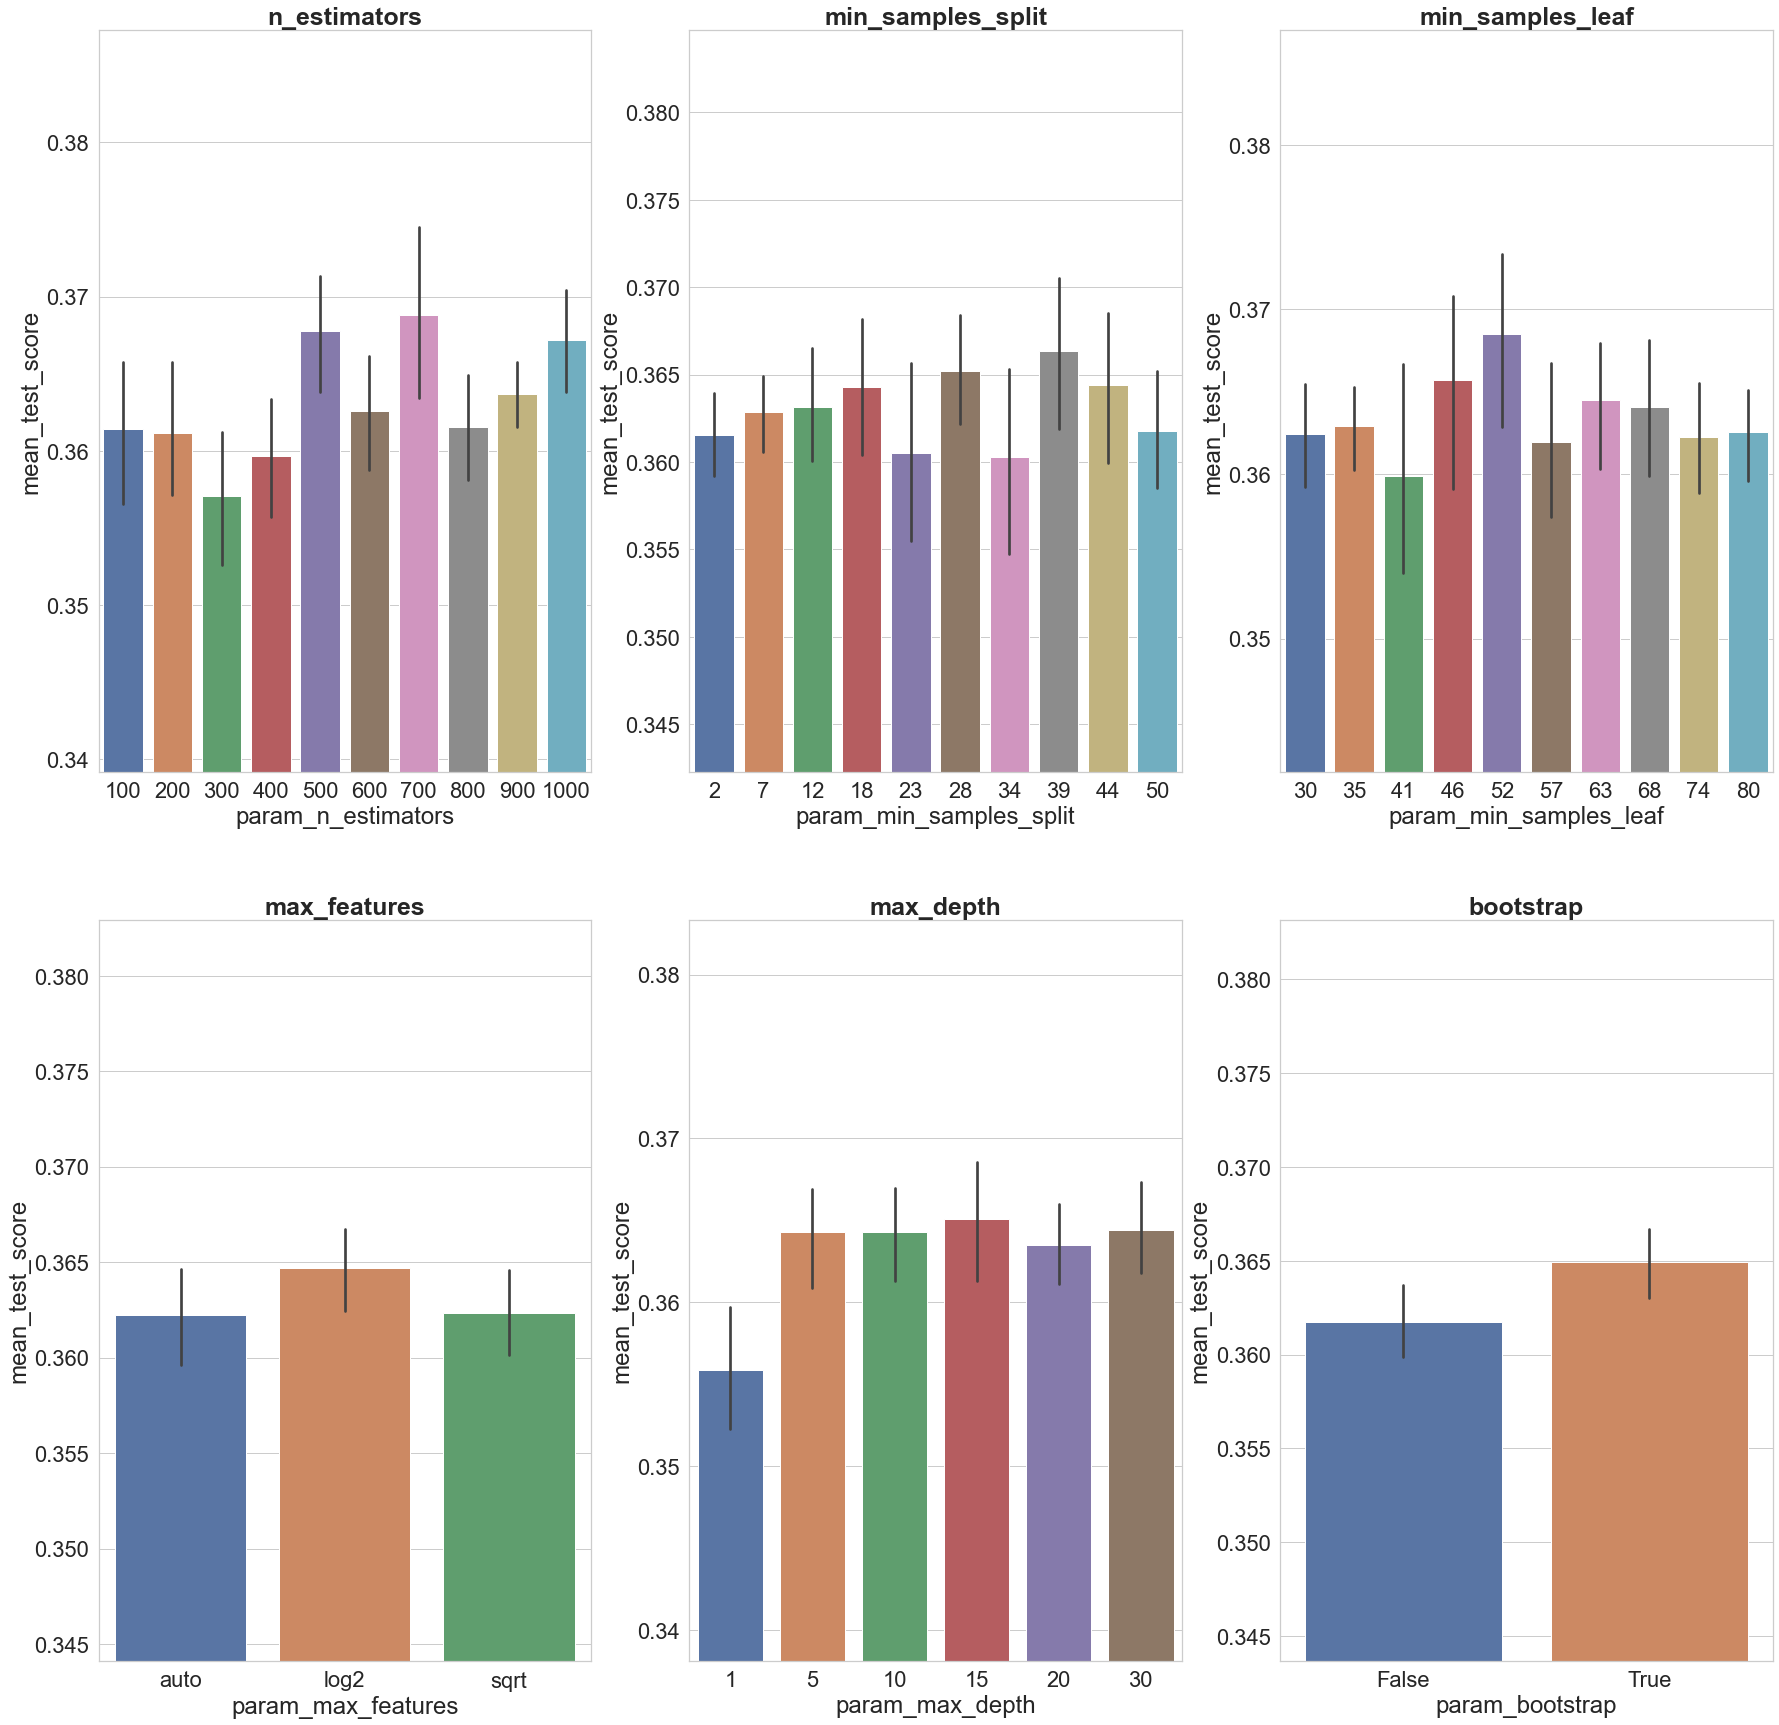

In [202]:
first_round_search(RandomForestClassifier(), param_grid, 100)

2 раунд

In [203]:
param_grid = {'n_estimators': [int(x) for x in np.linspace(start = 680, stop = 720, num = 10)],
              'max_features': ['log2',],
              'max_depth': [14, 15, 16],
              'min_samples_split': [11, 12, 13, 27, 28, 29, 38, 39, 40],
              'min_samples_leaf': [50, 51, 52, 53, 54],
              'bootstrap': [True, ]}
param_grid

{'n_estimators': [680, 684, 688, 693, 697, 702, 706, 711, 715, 720],
 'max_features': ['log2'],
 'max_depth': [14, 15, 16],
 'min_samples_split': [11, 12, 13, 27, 28, 29, 38, 39, 40],
 'min_samples_leaf': [50, 51, 52, 53, 54],
 'bootstrap': [True]}

In [204]:
grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, scoring='accuracy', n_jobs=-1, verbose=1, cv=3)
grid_result = grid.fit(train_x, train_y)

Fitting 3 folds for each of 1350 candidates, totalling 4050 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed: 12.4min
[Parallel(n_jobs=-1)]: Done 4050 out of 4050 | elapsed: 12.4min finished


In [205]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.387918 using {'bootstrap': True, 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 52, 'min_samples_split': 12, 'n_estimators': 680}


In [206]:
model_res(grid_result.best_estimator_)

Accuracy:  0.35901162790697677 

Confusion matrix: 
 [[  5  23  56]
 [ 51 214 276]
 [  5  30  28]]


### XGBoost

In [208]:
import xgboost as xgb

1 раунд

In [213]:
param_grid = {'n_estimators': [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)],
              'learning_rate': [0.01, 0.1, 0.2, 0,3],
              'max_depth': [1, 5, 10, 15],
              'gamma': [0, 0.1, 0.2],
              'min_child_weight': [0, 0.5, 1],
              'subsample': [0.7, 0.8, 0.9, 1],
              'colsample_bytree': [0.6, 0.8, 1],
              'reg_alpha': [0, 1e-2, 1, 1e1],
              'reg_lambda': [0, 1e-2, 1, 1e1]}
param_grid

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
 'learning_rate': [0.01, 0.1, 0.2, 0, 3],
 'max_depth': [1, 5, 10, 15],
 'gamma': [0, 0.1, 0.2],
 'min_child_weight': [0, 0.5, 1],
 'subsample': [0.7, 0.8, 0.9, 1],
 'colsample_bytree': [0.6, 0.8, 1],
 'reg_alpha': [0, 0.01, 1, 10.0],
 'reg_lambda': [0, 0.01, 1, 10.0]}

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   33.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.6min finished
C:\Users\Konstantin\.conda\envs\ml_hse\lib\site-packages\xgboost\sklearn.py:892: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[18:15:16] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


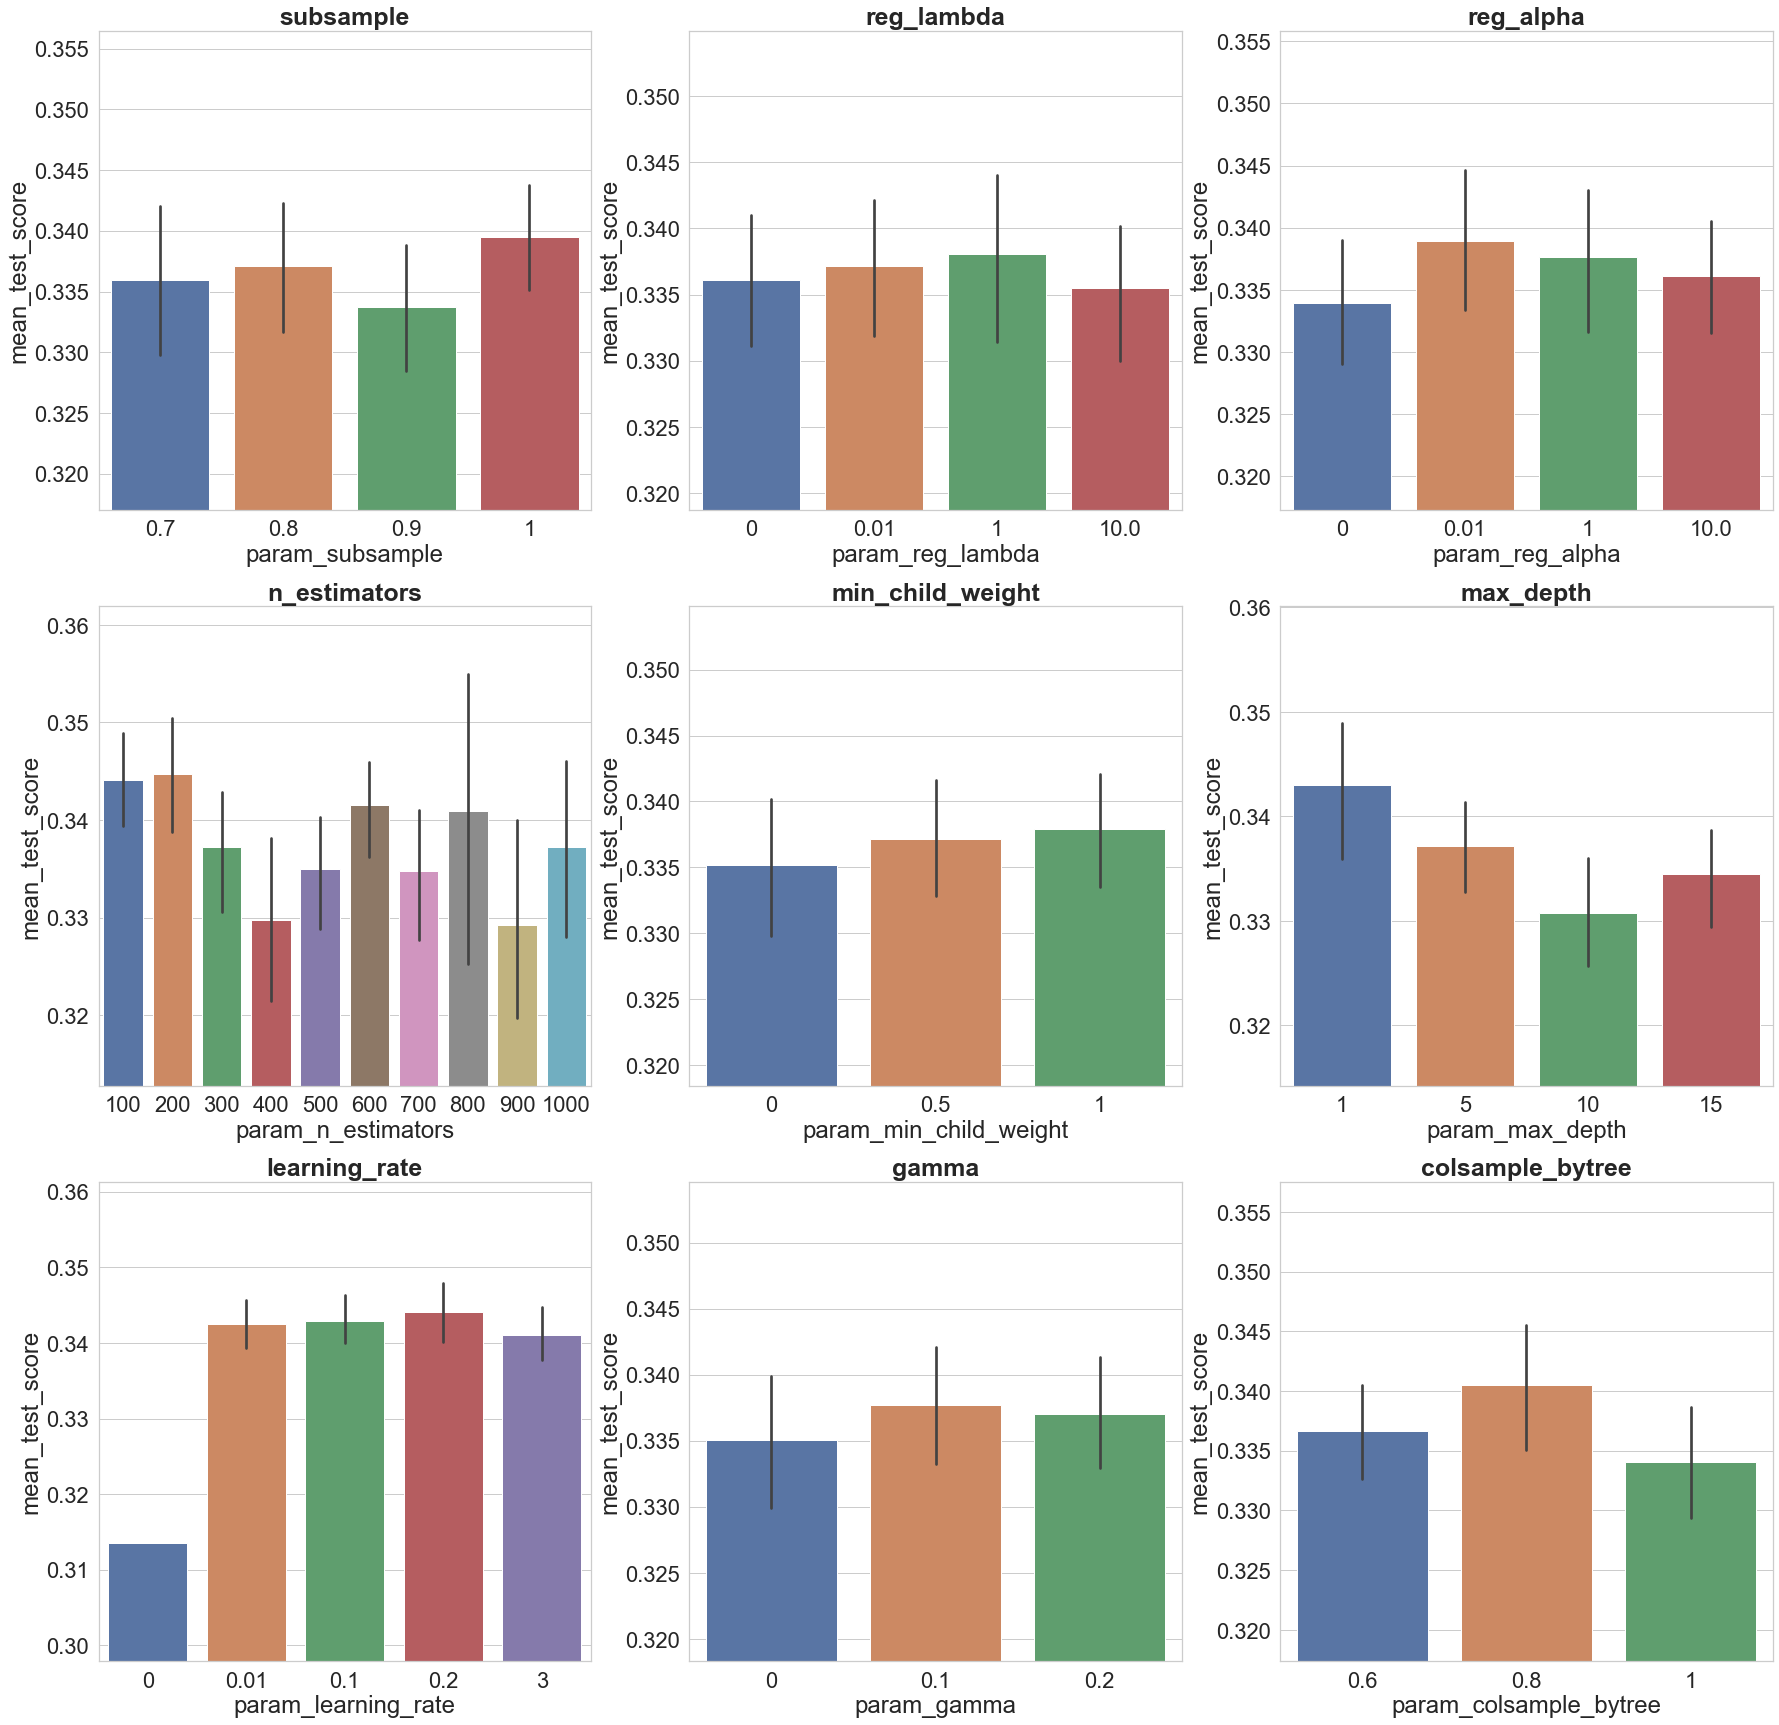

In [214]:
first_round_search(xgb.XGBRFClassifier(), param_grid, 100)

2 раунд

In [215]:
param_grid = {'n_estimators': [100, 200],
              'learning_rate': [0.2,],
              'max_depth': [1, 2, 3],
              'gamma': [0.09, 0.1, 0.15],
              'min_child_weight': [1,],
              'subsample': [1,],
              'colsample_bytree': [0.7, 0.8, 0.9],
              'reg_alpha': [0.01,],
              'reg_lambda': [1,]}
param_grid

{'n_estimators': [100, 200],
 'learning_rate': [0.2],
 'max_depth': [1, 2, 3],
 'gamma': [0.09, 0.1, 0.15],
 'min_child_weight': [1],
 'subsample': [1],
 'colsample_bytree': [0.7, 0.8, 0.9],
 'reg_alpha': [0.01],
 'reg_lambda': [1]}

In [216]:
grid = GridSearchCV(estimator=xgb.XGBRFClassifier(), param_grid=param_grid, scoring='accuracy', n_jobs=-1, verbose=1, cv=3)
grid_result = grid.fit(train_x, train_y)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 162 out of 162 | elapsed:   14.0s finished
C:\Users\Konstantin\.conda\envs\ml_hse\lib\site-packages\xgboost\sklearn.py:892: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[18:29:29] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [217]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.355604 using {'colsample_bytree': 0.8, 'gamma': 0.09, 'learning_rate': 0.2, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 1}


In [218]:
model_res(grid_result.best_estimator_)

[18:30:39] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy:  0.3953488372093023 

Confusion matrix: 
 [[ 10  33  41]
 [ 45 233 263]
 [  4  30  29]]


### SVM

In [219]:
from sklearn.svm import SVC

1 раунд

In [229]:
param_grid = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 'scale', 'auto'],
              'class_weight': [None, 'balanced'],
              'decision_function_shape': ['ovr', 'ovo']}
param_grid

{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
 'C': [0.1, 1, 10, 100, 1000],
 'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 'scale', 'auto'],
 'class_weight': [None, 'balanced'],
 'decision_function_shape': ['ovr', 'ovo']}

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    3.2s finished


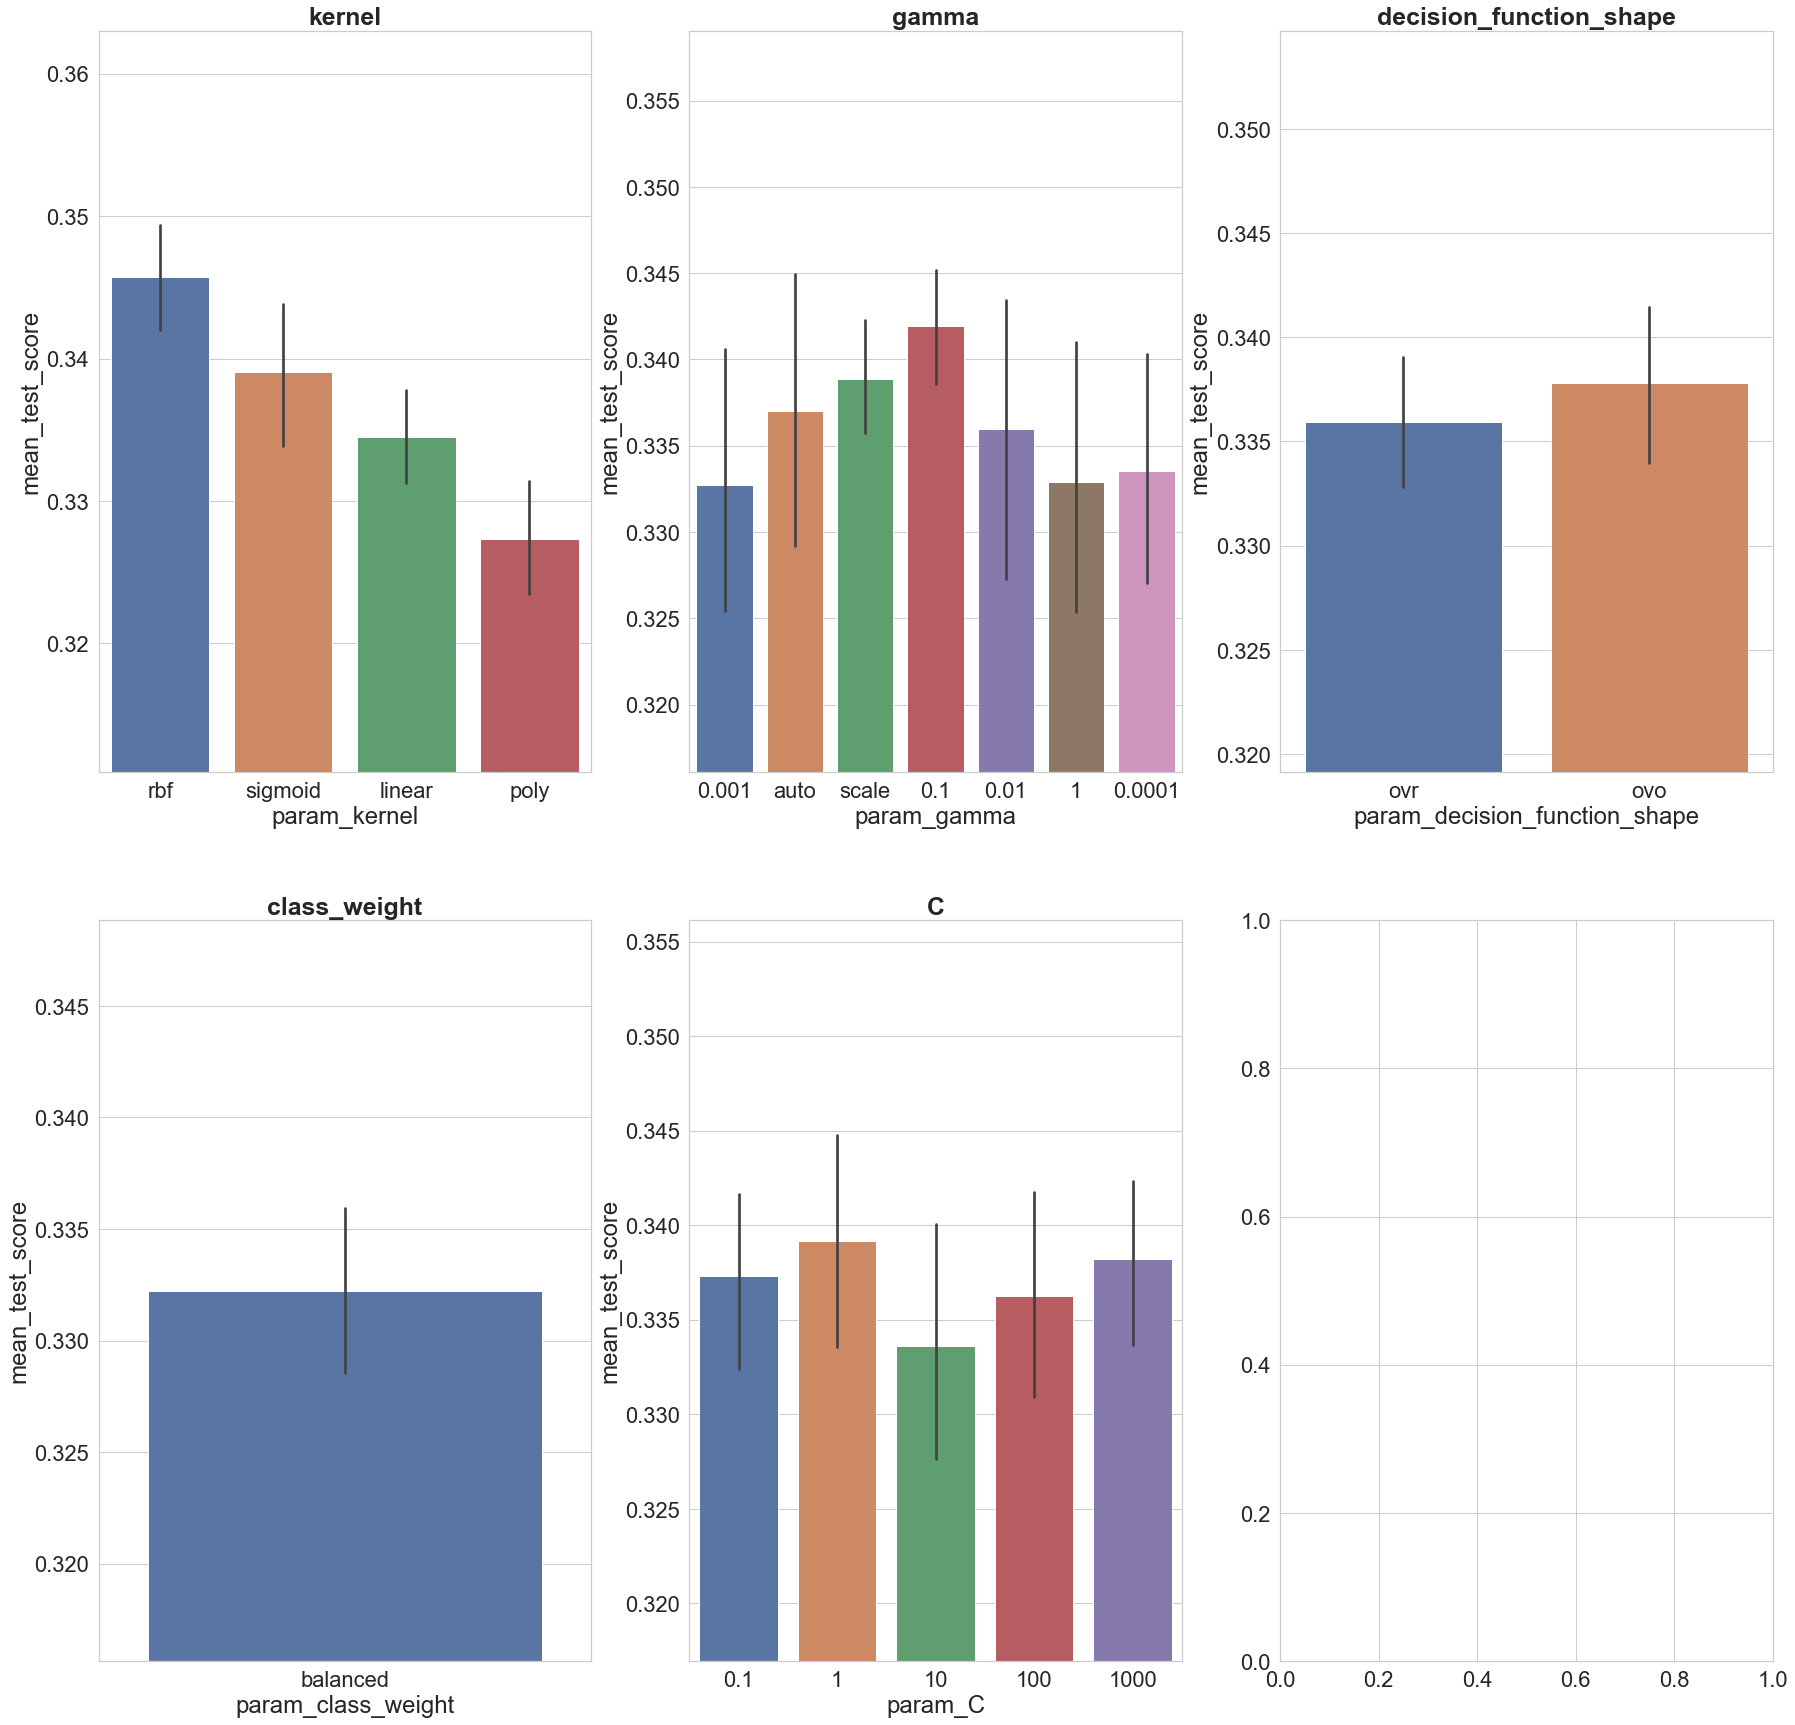

In [235]:
first_round_search(SVC(max_iter=10000), param_grid, 100)

2 раунд

In [236]:
param_grid = {'kernel': ['rbf',],
              'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 'scale', 'auto'],
              'class_weight': [None, 'balanced'],
              'decision_function_shape': ['ovr', 'ovo']}
param_grid

{'kernel': ['rbf'],
 'C': [0.1, 1, 10, 100, 1000],
 'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 'scale', 'auto'],
 'class_weight': [None, 'balanced'],
 'decision_function_shape': ['ovr', 'ovo']}

In [237]:
grid = GridSearchCV(estimator=SVC(max_iter=10000), param_grid=param_grid, scoring='accuracy', n_jobs=-1, verbose=1, cv=3)
grid_result = grid.fit(train_x, train_y)

Fitting 3 folds for each of 140 candidates, totalling 420 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 397 out of 420 | elapsed:    3.4s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 420 out of 420 | elapsed:    3.5s finished


In [238]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.378248 using {'C': 10, 'class_weight': None, 'decision_function_shape': 'ovr', 'gamma': 0.01, 'kernel': 'rbf'}


In [239]:
model_res(grid_result.best_estimator_)

Accuracy:  0.2877906976744186 

Confusion matrix: 
 [[ 17  28  39]
 [ 64 139 338]
 [  7  14  42]]
